In [15]:
!unzip "archive (1).zip"

Archive:  archive (1).zip
replace Test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [16]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [17]:
train = pd.read_csv("Train.csv")
valid = pd.read_csv("Valid.csv")
test = pd.read_csv("Test.csv")

print(train.head())

                                                text  label
0  I grew up (b. 1965) watching and loving the Th...      0
1  When I put this movie in my DVD player, and sa...      0
2  Why do people who do not know what a particula...      0
3  Even though I have great interest in Biblical ...      0
4  Im a die hard Dads Army fan and nothing will e...      1


In [18]:
print("Train shape:", train.shape)
print(train['label'].value_counts())

Train shape: (40000, 2)
label
0    20019
1    19981
Name: count, dtype: int64


In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [20]:
train['clean_text'] = train['text'].apply(preprocess_text)
valid['clean_text'] = valid['text'].apply(preprocess_text)
test['clean_text'] = test['text'].apply(preprocess_text)

train[['text','clean_text']].head()

,text,clean_text
0,I grew up (b. 1965) watching and loving the Th...,grew b watching loving thunderbird mate school...
1,"When I put this movie in my DVD player, and sa...",put movie dvd player sat coke chip expectation...
2,Why do people who do not know what a particula...,people know particular time past like feel nee...
3,Even though I have great interest in Biblical ...,even though great interest biblical movie bore...
4,Im a die hard Dads Army fan and nothing will e...,im die hard dad army fan nothing ever change g...


In [21]:
X_train = train['clean_text']
y_train = train['label']

X_valid = valid['clean_text']
y_valid = valid['label']

X_test = test['clean_text']
y_test = test['label']

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

In [23]:
#logistic regression
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [24]:
#naive bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

In [25]:
#desion tree
dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

In [26]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.8860
1          Naive Bayes    0.8632
2        Decision Tree    0.7128


In [27]:
def evaluate(y_true, y_pred, name):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

In [28]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")


 Logistic Regression
Accuracy: 0.886
Precision: 0.8807556080283353
Recall: 0.8934131736526946
F1 Score: 0.8870392390011891

 Naive Bayes
Accuracy: 0.8632
Precision: 0.8586057502953919
Recall: 0.8702594810379242
F1 Score: 0.8643933386201428

 Decision Tree
Accuracy: 0.7128
Precision: 0.7137145141943223
Recall: 0.7125748502994012
F1 Score: 0.7131442269276868


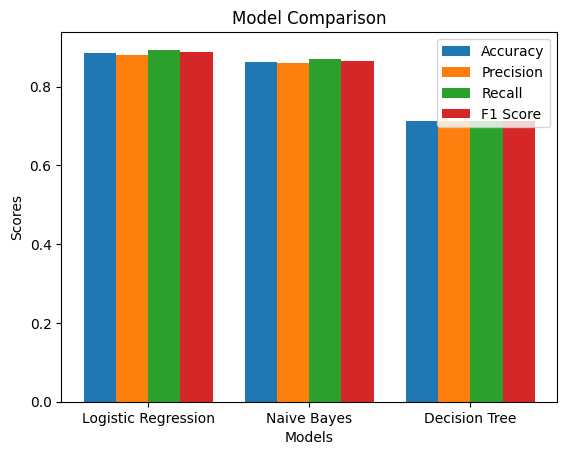

In [29]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Naive Bayes", "Decision Tree"]

accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

precision = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_dt)
]

recall = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_dt)
]

f1 = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_dt)
]

x = np.arange(len(models))
width = 0.2

plt.figure()

plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Model Comparison")

plt.legend()
plt.show()